In [6]:
from __future__ import annotations

%load_ext autoreload
%autoreload 2
import math
import random
import requests
import time
from dataclasses import dataclass
from ratingcalc import binsearch, calcperf

ratinglist = {}
ratinglist_json = requests.get("https://codeforces.com/api/user.ratedList").json()
for user in ratinglist_json["result"]:
    ratinglist[user["handle"]] = user["rating"]

print(f'Total rated users: {len(ratinglist)}')
print(list(ratinglist.items())[:10])


@dataclass
class Contest:
    contestant_ratings: list[int]
    perfs: dict[int, float]

    @classmethod
    def fetch(cls, contest_id: int) -> Contest:
        json = requests.get(f'https://codeforces.com/api/contest.standings?contestId={contest_id}').json()
        cont_ratings = []
        for entry in json['result']['rows']:
            if len(entry['party']['members']) > 1:
                continue
            handle = entry['party']['members'][0]['handle']
            cont_ratings.append(ratinglist.get(handle, 1400))
        perfs = calcperf(cont_ratings)
        return cls(cont_ratings, perfs)


def sim(contest: Contest, r: int, trials: int) -> float:
    """Simulate :trials: trials of a user rated :r:. Return the average rating delta.
    Is quite slow, O(n) where n is number of participants, per trial. There may be a way to sample the distribution faster, but I'm not sure.
    """
    expect_place: float = contest.perfs[r]
    sum_delta = 0.0
    for _ in range(trials):
        placing = 0
        for other_rating in contest.contestant_ratings:
            loss_chance = 1 / (1 + math.exp((r - other_rating) / 173.7178))
            if random.random() < loss_chance:
                placing += 1
        geomean_placing = math.sqrt((placing+1) * (expect_place+1)) - 1  # need to convert to 1-based
        perf_for_delta = binsearch(contest.perfs, geomean_placing)
        delta = (perf_for_delta - r) / 2
        sum_delta += delta
    return sum_delta / trials


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Total rated users: 133583
[('Benq', 3792), ('jiangly', 3728), ('EvenImage', 3682), ('zhoukangyang', 3670), ('Kevin114514', 3625), ('Geothermal', 3569), ('maroonrk', 3555), ('strapple', 3515), ('tourist', 3439), ('dXqwq', 3436)]


In [8]:
# Last 10 div1 or div1+2
# CONTESTS = [
#     2239, 2237, 2229, 2223, 2219,
#     2211, 2207, 2201, 2196, 2187,
# ]
# Historic div1 or div1+2 from the end of 2024 (this is when tourist was 4000)
CONTESTS = [
    2053, 2048, 2046, 2034, 2039,
    2029, 2035, 2023, 2018, 2006,
]
RATINGS_TO_CHECK = list(range(2400, 4001, 100))
TRIALS = 1000


# rating -> [list of average deltas for each contest]
results: dict[int, list[float]] = {r: [] for r in RATINGS_TO_CHECK}

start = time.time()
for c in CONTESTS:
    print(f'Contest {c}  [{time.time()-start:.1f}]')
    contest = Contest.fetch(c)
    print(f'  Fetched x{len(contest.contestant_ratings)}  [{time.time()-start:.1f}]')
    for r in RATINGS_TO_CHECK:
        avg_delta = sim(contest, r, TRIALS)
        print(f'  Rating {r}: {avg_delta:.2f}  [{time.time()-start:.1f}]')
        results[r].append(avg_delta)


print(f'\nFinished!  [{time.time()-start:.1f}]\n')
print(results)
print(f'\nAverages:\n')
print({k: sum(v)/len(v) for k, v in results.items()})

Contest 2053  [0.0]
  Fetched x14757  [4.3]
  Rating 2400: 0.35  [6.1]
  Rating 2500: 0.31  [8.0]
  Rating 2600: 0.24  [9.8]
  Rating 2700: 0.38  [11.6]
  Rating 2800: 0.52  [13.5]
  Rating 2900: 0.59  [15.6]
  Rating 3000: 0.66  [17.4]
  Rating 3100: 1.51  [19.2]
  Rating 3200: 1.44  [20.9]
  Rating 3300: 1.16  [22.8]
  Rating 3400: 2.79  [24.5]
  Rating 3500: 2.98  [26.3]
  Rating 3600: 4.58  [28.1]
  Rating 3700: 5.63  [29.9]
  Rating 3800: 8.03  [31.7]
  Rating 3900: 13.32  [33.4]
  Rating 4000: 19.41  [35.2]
Contest 2048  [35.2]
  Fetched x15064  [40.5]
  Rating 2400: 0.48  [42.3]
  Rating 2500: 0.31  [44.1]
  Rating 2600: 0.43  [45.9]
  Rating 2700: 0.41  [47.7]
  Rating 2800: 0.36  [49.5]
  Rating 2900: 0.62  [51.3]
  Rating 3000: 0.56  [53.1]
  Rating 3100: 1.04  [54.8]
  Rating 3200: 0.82  [56.6]
  Rating 3300: 1.60  [58.4]
  Rating 3400: 1.65  [60.2]
  Rating 3500: 2.12  [62.0]
  Rating 3600: 4.14  [63.7]
  Rating 3700: 7.08  [65.5]
  Rating 3800: 10.21  [67.3]
  Rating 3900:

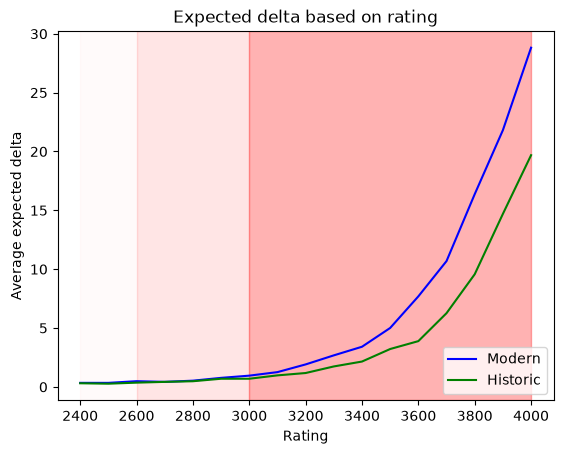

In [22]:
from matplotlib import pyplot as plt


r1 = {2400: 0.34255, 2500: 0.34125, 2600: 0.4843, 2700: 0.42805, 2800: 0.5279499999999999, 2900: 0.7673, 3000: 0.9544, 3100: 1.2544499999999998, 3200: 1.9088, 3300: 2.67815, 3400: 3.40995, 3500: 5.0063, 3600: 7.690299999999999, 3700: 10.6883, 3800: 16.37225, 3900: 21.8109, 4000: 28.81755}
r2 = {2400: 0.3076, 2500: 0.27115, 2600: 0.35995, 2700: 0.426, 2800: 0.4801, 2900: 0.69155, 3000: 0.6923, 3100: 0.978, 3200: 1.1778499999999998, 3300: 1.73655, 3400: 2.15265, 3500: 3.21725, 3600: 3.8872999999999998, 3700: 6.2631, 3800: 9.5688, 3900: 14.697899999999999, 4000: 19.68495}
r1i = list(r1.items())
r2i = list(r2.items())
x1 = [x[0] for x in r1i]
y1 = [x[1] for x in r1i]
x2 = [x[0] for x in r2i]
y2 = [x[1] for x in r2i]


fig, ax = plt.subplots()
ax.axvspan(2400, 2600, color='red', alpha=0.02)
ax.axvspan(2600, 3000, color='red', alpha=0.1)
ax.axvspan(3000, 4000, color='red', alpha=0.3)
plt.plot(x1, y1, label='Modern', color='blue')
plt.plot(x2, y2, label='Historic', color='green')
plt.xlabel('Rating')
plt.ylabel('Average expected delta')
plt.title('Expected delta based on rating')
plt.legend()
plt.savefig('output.png', dpi=800)

In [25]:
def sim(contest: Contest, r_nominal: int, r_real: int, trials: int) -> float:
    """Simulate again, but with user's nominal rating and their real skill being different."""
    expect_place: float = contest.perfs[r_nominal]
    sum_delta = 0.0
    for _ in range(trials):
        placing = 0
        for other_rating in contest.contestant_ratings:
            loss_chance = 1 / (1 + math.exp((r_real - other_rating) / 173.7178))
            if random.random() < loss_chance:
                placing += 1
        geomean_placing = math.sqrt((placing+1) * (expect_place+1)) - 1  # need to convert to 1-based
        perf_for_delta = binsearch(contest.perfs, geomean_placing)
        delta = (perf_for_delta - r_nominal) / 2
        sum_delta += delta
    return sum_delta / trials


print('Fetching...')
CONTESTS = [
    2239, 2237, 2229, 2223, 2219,
    2211, 2207, 2201, 2196, 2187,
]
CONTESTS = [Contest.fetch(c) for c in CONTESTS]
print('Fetching complete!')

Fetching...
Fetching complete!


In [27]:
COMBINATIONS = [
    # Nominal, real
    (3500, 3490), (3500, 3480),
    (3400, 3390), (3400, 3380),
]

for nom, real in COMBINATIONS:
    print(f'Nominal: {nom}, Real: {real}  (would be {nom-real} of inflation)')
    sum = 0
    for contest in CONTESTS:
        avg_delta = sim(contest, nom, real, TRIALS)
        sum += avg_delta
    print(f'  Average delta: {sum/len(CONTESTS):.1f}')

Nominal: 3500, Real: 3490  (would be 10 of inflation)
  Average delta: 2.1
Nominal: 3500, Real: 3480  (would be 20 of inflation)
  Average delta: -0.3
Nominal: 3400, Real: 3390  (would be 10 of inflation)
  Average delta: 1.2
Nominal: 3400, Real: 3380  (would be 20 of inflation)
  Average delta: -1.7
